In [1]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.7 MB/s eta 0:00:00


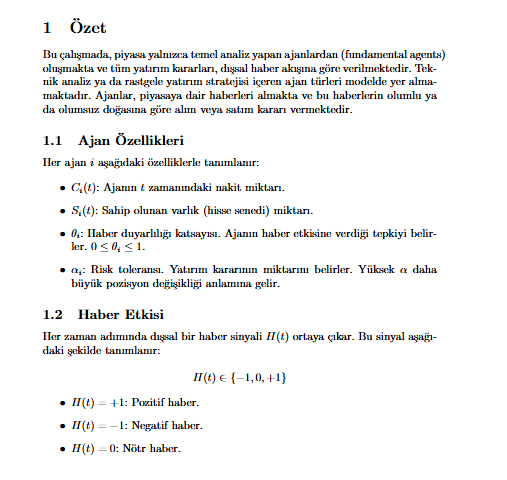

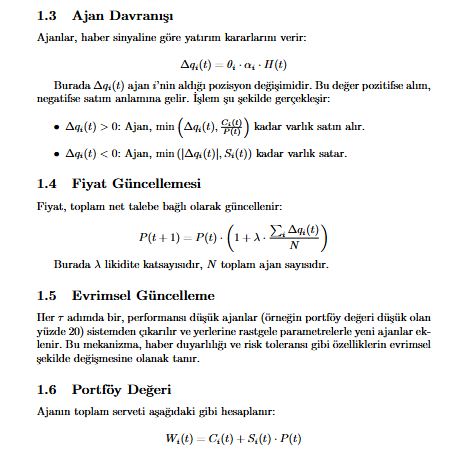

Model Verileri:
   Price  Total Shares  Total Cash  Total Wealth  News Signal
0  100.0             0     50000.0       50000.0            0
1  108.3            83     41700.0       50688.9            1
2  108.3            83     41700.0       50688.9            0
3  108.3            83     41700.0       50688.9            0
4  108.3            83     41700.0       50688.9            0

Ajan Verileri (İlk Adım İçin):
                     Cash  Shares       Wealth  Position Change
Step AgentID                                                   
1    1        1000.000000       0  1000.000000                0
     2        1000.000000       0  1000.000000                0
     3        1000.000000       0  1000.000000                0
     4        1000.000000       0  1000.000000                0
     5        1000.000000       0  1000.000000                0
...                   ...     ...          ...              ...
100  46        937.571527       1  1024.984624               -1
    

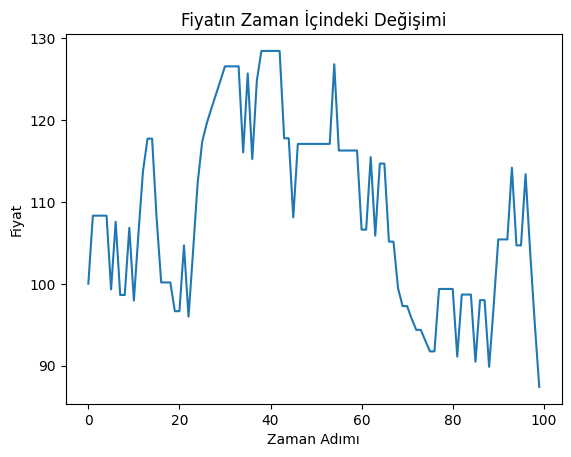

In [26]:

import random

class FundamentalAgent(mesa.Agent):
    """
    Piyasada temel analize göre alım/satım yapan ajan.
    """
    def __init__(self, model, initial_cash, initial_shares, sensitivity, risk_tolerance):
        super().__init__(model)
        self.cash = initial_cash
        self.shares = initial_shares
        self.sensitivity = sensitivity      # θi: Haber duyarlılığı [0, 1]
        self.risk_tolerance = risk_tolerance # αi: Risk toleransı (pozisyon değişim miktarını belirler)
        self.position_change_this_step = 0 # Bu adımda gerçekleştirilen pozisyon değişimi (∆qi(t))

    def step(self):
        # Modelden güncel haber sinyalini al
        news_signal = self.model.current_news_signal

        # Beklenen pozisyon değişimini hesapla: ∆qi(t) = θi * αi * H(t)
        # Özetinizdeki formülü doğrudan kullanıyoruz.
        # αi'nin pozisyon değişim miktarını belirlediği belirtilmiş.
        # H(t)'nin -1, 0, +1 olması pozisyonun yönünü belirliyor.
        # θi ve αi'nin çarpımı pozisyon değişiminin büyüklüğünü belirliyor.
        desired_position_change = self.sensitivity * self.risk_tolerance * news_signal

        price = self.model.current_price
        actual_position_change = 0

        if desired_position_change > 0:
            # Alım yapmak istiyor
            # Alabileceği maksimum hisse miktarı: cash / price
            max_shares_to_buy = self.cash // price if price > 0 else 0 # Fiyat sıfırsa alım yapamaz

            # Almak istediği miktar (desired_position_change) ondalıklı olabilir.
            # Alabileceği maksimum miktarın minimumu kadar alır, bu da ondalıklı olabilir.
            shares_to_buy_float = min(desired_position_change, max_shares_to_buy)

            # Hisse miktarını tamsayıya yuvarla (örneğin, tabana yuvarla)
            shares_to_buy = int(shares_to_buy_float)

            if shares_to_buy > 0:
                cost = shares_to_buy * price
                if self.cash >= cost: # Nakit kontrolü
                    self.shares += shares_to_buy
                    self.cash -= cost
                    actual_position_change = shares_to_buy
                # else: Nakit yetersiz, alım yapamaz



        elif desired_position_change < 0:
            # Satış yapmak istiyor
            # Satmak istediği miktar: |desired_position_change| ondalıklı olabilir.
            shares_to_sell_float = abs(desired_position_change)

            # Sahip olduğu hisse miktarı ondalıklı olabilir.
            # Satmak istediği miktarın minimumu kadar satar, bu da ondalıklı olabilir.
            actual_shares_to_sell_float = min(shares_to_sell_float, self.shares)

            # Hisse miktarını tamsayıya yuvarla (örneğin, tavana yuvarla veya en yakına)
            # Burada satılacak hisseyi tamsayı yaparken dikkatli olmak lazım.
            # Elimizde olan hisse sayısını aşmamalı.
            # Basitçe tabana yuvarlayalım ve sonra elimizdeki hisse sayısıyla tekrar min alalım.
            actual_shares_to_sell = int(actual_shares_to_sell_float)
            actual_shares_to_sell = min(actual_shares_to_sell, int(self.shares)) # Elimizdekinden fazla satmamak için tamsayı halini kontrol et


            if actual_shares_to_sell > 0:
                revenue = actual_shares_to_sell * price
                self.shares -= actual_shares_to_sell
                self.cash += revenue
                actual_position_change = -actual_shares_to_sell # Satış olduğu için negatif

        # Bu adımda gerçekleşen pozisyon değişimini kaydet
        self.position_change_this_step = actual_position_change

    def get_wealth(self):
        # Basit bir varlık hesaplama
        return self.cash + self.shares * self.model.current_price if self.model.current_price > 0 else self.cash


class FinancialModel(mesa.Model):
    """
    Temel analiz yapan ajanlardan oluşan bir finans piyasası modeli.
    """
    def __init__(self, num_agents, initial_price, liquidity_lambda, initial_cash_per_agent=1000, initial_shares_per_agent=0):
        super().__init__()
        self.num_agents = num_agents
        self.current_price = initial_price
        self.liquidity_lambda = liquidity_lambda # λ likidite katsayısı



        # Ajanları oluştur
        self.agentss = []
        for i in range(self.num_agents):
            # Rastgele duyarlılık (0 ile 1 arası) ve risk toleransı (pozitif bir değer) ata
            sensitivity = random.uniform(0, 1)
            risk_tolerance = random.uniform(1, 10) # Örnek değerler, duruma göre ayarlanabilir

            agent = FundamentalAgent(
                self,
                initial_cash=initial_cash_per_agent,
                initial_shares=initial_shares_per_agent,
                sensitivity=sensitivity,
                risk_tolerance=risk_tolerance
            )
            self.agents.add(agent)
            self.agentss.append(agent) # Agent listesine ekleyelim, toplam Δq hesaplamak için lazım olacak

        # Data Collector ekleyebiliriz (opsiyonel ama kullanışlı)
        self.datacollector = mesa.DataCollector(
            model_reporters={"Price": "current_price",
                             "Total Shares": lambda m: sum([a.shares for a in m.agents]),
                             "Total Cash": lambda m: sum([a.cash for a in m.agents]),
                             "Total Wealth": lambda m: sum([a.get_wealth() for a in m.agents]),
                             "News Signal": "current_news_signal"},
            agent_reporters={"Cash": lambda a: a.cash,
                             "Shares": lambda a: a.shares,
                             "Wealth": lambda a: a.get_wealth(),
                             "Position Change": lambda a: a.position_change_this_step}
        )

        self.current_news_signal = 0 # İlk adımda haber sinyali

    def step(self):
        # 1. Haber Sinyalini Oluştur
        self.current_news_signal = random.choice([-1, 0, 1])

        # 2. Ajanların Adımını Çalıştır (Bu, agent.step() metodunu çağırır ve pozisyon değişimlerini kaydeder)
        self.agents.do("step")

        # 3. Toplam Net Talebi Hesapla: Σ ∆qi(t)
        # Her ajanın step metodunda kaydettiği position_change_this_step değerlerini topluyoruz
        total_net_demand = sum([a.position_change_this_step for a in self.agents])

        # 4. Fiyatı Güncelle: P(t+1) = P(t) * (1 + λ * (Σ ∆qi(t) / N))
        # Fiyatın negatif olmaması için kontrol ekleyebiliriz
        price_multiplier = 1 + self.liquidity_lambda * (total_net_demand / self.num_agents)
        self.current_price = self.current_price * price_multiplier
        # Fiyatın en az 1 gibi bir alt sınırda kalmasını sağlayabiliriz (opsiyonel, model tanımında yok ama pratik olabilir)
        # self.current_price = max(1.0, self.current_price)


        # Veri Topla (Opsiyonel)
        self.datacollector.collect(self)

# Modelin çalıştırılması için örnek kullanım:
if __name__ == "__main__":
    num_agents = 50
    initial_price = 100
    liquidity_lambda = 0.05 # Örnek likidite katsayısı
    num_steps = 100

    model = FinancialModel(num_agents, initial_price, liquidity_lambda)

    for i in range(num_steps):
        model.step()

    # Sonuçları incelemek için DataCollector'ı kullanabilirsiniz
    model_data = model.datacollector.get_model_vars_dataframe()
    agent_data = model.datacollector.get_agent_vars_dataframe()

    print("Model Verileri:")
    print(model_data.head())

    print("\nAjan Verileri (İlk Adım İçin):")
    print(agent_data)

    # Örnek: Fiyatın zaman içindeki değişimini çizdirebilirsiniz (matplotlib gerektirir)
    try:
        import matplotlib.pyplot as plt
        model_data["Price"].plot(title="Fiyatın Zaman İçindeki Değişimi")
        plt.xlabel("Zaman Adımı")
        plt.ylabel("Fiyat")
        plt.show()
    except ImportError:
        print("Matplotlib yüklü değil. Grafik çizilemedi.")

(Σ ∆qi(t) / N) ifadesinde toplam talebi, toplam ajan sayısına bölmenin mantığı nedir, burada toplam ajan sayısı yerine toplam hisse miktarı gibi başka bir değişken daha mantıklı değil mi

(Σ ∆qi(t) / N) ifadesinde toplam net talebin (Σ ∆qi(t)), toplam ajan sayısına (N) bölünmesinin mantığı, genellikle bir ortalama talep veya piyasa baskısı ölçüsü elde etmek için kullanılır. Bu, fiyat üzerindeki etkinin kişi başına düşen talebe veya piyasaya katılan aktif oyuncu sayısına bağlı olduğunu varsayan bir modelleme tercihidir.

Burada birkaç olası mantık yatar:

Ortalama Ajan Etkisi: Model, her bir ajanın piyasada bir "oyuncu" olduğunu ve fiyat değişiminin, bu oyuncuların ortalama olarak ne kadar pozisyon değiştirmek istediğine bağlı olduğunu varsayıyor olabilir. Büyük bir ajan topluluğundaki ortalama talep, fiyat üzerindeki genel baskıyı temsil eder.
Piyasa Yapısı ve Likidite: λ (likidite katsayısı) ile birlikte bu ifade, piyasanın ne kadar "derin" veya "likit" olduğunu yansıtabilir. Toplam talep aynı kalsa bile, daha fazla ajanın (daha büyük N) olduğu bir piyasada, kişi başına düşen talep daha düşüktür ve bu da fiyat üzerindeki etkinin daha az keskin olmasını sağlayabilir. Tersine, az sayıda ajanın olduğu bir piyasada (daha küçük N), toplam talep kişi başına daha fazla düşer ve fiyat daha dramatik tepki verebilir. N'ye bölme, toplam talebi standardize ederek farklı büyüklükteki piyasaları karşılaştırmaya yardımcı olabilir.
Piyasa Katılımcılarının Ağırlığı: Model, her ajanın (ve dolayısıyla her ∆qi(t)'nin) fiyat üzerindeki etkisinin, piyasadaki toplam katılımcı sayısıyla ilişkili olduğunu varsayabilir. Talep, tek bir büyük oyuncudan değil, tüm ajanların toplamından geldiği için, bu toplamı ajan sayısına bölmek, her bir ajanın ortalama katkısının fiyata nasıl yansıdığını modelleyebilir.
Basitleştirme: Bu ifade, daha karmaşık bir piyasa mikroyapısı modelini basitleştirmenin bir yolu olabilir. Gerçek piyasalarda fiyat, emir defterindeki (order book) alım ve satım emirlerinin eşleşmesiyle belirlenir. Modelinizde doğrudan bir emir defteri olmadığı için, toplam net talep, emir defterindeki arz ve talebin bir vekil (proxy) değişkeni olarak kullanılıyor olabilir. N'ye bölme, bu vekil değişkeni, piyasanın genel "kapasitesi" veya "kalabalığı" ile ilişkilendirebilir.
Toplam Hisse Miktarına Bölmek Daha Mantıklı Olabilir mi?

Toplam hisse miktarı (örn: dolaşımdaki hisse sayısı veya ajanların sahip olduğu toplam hisse), genellikle şirketin büyüklüğünü veya piyasa değerini yansıtan bir ölçüdür. Toplam talebi bu miktara bölmek de farklı bir mantığa dayanır:

Piyasa Değerine Göre Etki: Fiyat üzerindeki etkinin, piyasanın büyüklüğüne (örneğin, dolaşımdaki hisse sayısına oranla) bağlı olduğunu varsayar. Aynı miktardaki toplam talep, daha küçük bir piyasa değerine (daha az hisse sayısına) sahip bir enstrümanın fiyatını daha fazla etkileyebilir.
Bu yaklaşım da kendi içinde tutarlı bir modelleme seçeneği olabilir. Hangi ifadenin (N'ye bölme vs. Toplam Hisse'ye bölme) "daha mantıklı" olduğu, modelin temsil etmeye çalıştığı spesifik piyasa dinamiklerine ve modelleme amacına bağlıdır.

Eğer modelin amacı, aktif oyuncu sayısının piyasa tepkisini nasıl etkilediğini vurgulamaksa, N'ye bölmek mantıklıdır.
Eğer modelin amacı, enstrümanın göreceli büyüklüğüne (hisse sayısına) göre talep şoklarının etkisini modellemekse, toplam hisse miktarına bölmek daha uygun olabilir.
Sizin mevcut modelinizdeki (Σ ∆qi(t) / N) ifadesi, talebin piyasadaki ajan sayısına göre normalize edildiğini ve fiyat üzerindeki etkinin ortalama ajan davranışından kaynaklandığını varsayıyor. Bu, agent-based modelleme bağlamında sıkça karşılaşılan bir yaklaşımdır ve piyasanın "kalabalıklaşmasının" veya "incelmesinin" fiyat dinamiklerini nasıl etkilediğini modellemek için kullanılabilir.

Modelin amacına ve temsil etmek istediğiniz piyasa özelliklerine göre bu formülü değiştirmeyi düşünebilirsiniz. Ancak mevcut hali, "ortalama ajan talebinin" fiyata etkisini yansıtma mantığına dayanmaktadır.

   aşağıdaki kodda riskten kaçınmadan daha büyük bir beklenen getiri yoksa alım yapmaya izin vermiyor diyorum, katılıyor musun:
   
   
   
    # Karar mekanizması: risk duyarlılığına göre al/sat
    if expected_return > self.risk_aversion:
        # Alım yap
        price = self.model.price
        shares_to_buy = self.cash // price
        self.shares += shares_to_buy
        self.cash -= shares_to_buy * price
    elif expected_return < -self.risk_aversion:
        # Satış yap
        price = self.model.price
        self.cash += self.shares * price
        self.shares = 0

Evet, kesinlikle katılıyorum. Verdiğiniz kod parçasına göre:

Alım Koşulu: if expected_return > self.risk_aversion:
Bu koşul, ancak ajanın hesapladığı expected_return değeri, ajanın kendi self.risk_aversion değerinden kesinlikle daha büyükse (yani pozitif ve yeterince büyükse) doğru olur.
Eğer expected_return değeri self.risk_aversion değerine eşit veya daha küçükse (negatif, sıfır veya pozitif ama eşik değerinden küçükse), bu if bloğuna girilmez.


peki aynı şeyi yukarıdaki kod için de söyleyebilir miyiz: (desired_position_change = self.sensitivity * self.risk_tolerance * news_signal)


önceki kodunuzdaki "riskten kaçınmadan daha büyük bir beklenen getiri yoksa alım yapmaya izin vermiyor" (bir eşik olarak riskten kaçınma) mantığı bu yapı için geçerli DEĞİLDİR.

Neden?

Bu yapı, desired_position_change pozitif olduğu sürece alım yapmaya çalışır. desired_position_change değeri, self.sensitivity, self.risk_tolerance ve news_signal'ın çarpımıdır. Eğer self.sensitivity > 0, self.risk_tolerance > 0 ve news_signal > 0 ise, desired_position_change pozitif olacaktır.
Burada self.risk_tolerance (önceki kodunuzdaki self.risk_aversion ile farklı bir rol oynuyor gibi görünüyor), alım/satım yapma veya yapmama kararının eşiği olarak değil, alınmak/satılmak istenen pozisyon değişiminin büyüklüğünü belirlemek için kullanılır.
Alım yapılabilmesi için tek kısıtlama, ajanın yeterli nakite sahip olmasıdır (if self.cash >= cost: kontrolü). Eğer desired_position_change > 0 ise ve ajan yeterli nakite sahipse, alım gerçekleşecektir. self.risk_tolerance değeri, alım yapma kararını doğrudan "evet" veya "hayır" olarak etkilemez; sadece ne kadar hisse almak istediğini belirler.
Özetle:

İlk kodunuzda self.risk_aversion bir karar eşiğiydi: expected_return bu eşiği aşmazsa alım yapılmazdı. İkinci (tamamlanmış varsayılan) kodunuzda ise, desired_position_change pozitif olduğu sürece alım yapma denemesi gerçekleşir ve tek sınırlayıcı faktör nakit miktarıdır. self.risk_tolerance ise alınmak istenen miktarı etkileyen bir çarpan rolündedir. Dolayısıyla, aynı şeyi (riskten kaçınmanın bir eşik olarak kullanılması) bu yapı için söyleyemeyiz.







peki bu modelde de expected_return, risk_aversion yada risk_tolerance ilişkisini kuralım

Harika bir fikir! Özetinizdeki "beklenen getiri" veya "haber etkisi" ile "riskten kaçınma" veya "risk toleransı" arasında bir ilişki kurarak ajan davranışını daha incelikli hale getirebiliriz. Özetinizdeki ajan tanımında risk toleransı ($\alpha_i$$\alpha_i$) "Yatırım kararının miktarını belirler" deniyor, bu da onu pozisyon büyüklüğü ile ilişkilendiriyor. Ama biz, riskten kaçınma kavramını da ekleyerek, ajanın pozisyon değiştirme kararını da etkilemesini sağlayabiliriz.

İşte bu modeli, "beklenen etki" (haber * duyarlılık) ile bir "risk eşiği" (riskten kaçınma veya risk toleransına bağlı bir değer) arasında bir karşılaştırma yaparak alım/satım kararını veren hale nasıl dönüştürebileceğiniz:

Yaklaşım: Beklenen Etki > Risk Eşiği ise Pozisyon Değiştir

Bu yaklaşımda, ajanın news_signal * self.sensitivity ile hesapladığı "beklenen etki", bir "risk eşiği"ni aşarsa, ajan pozisyon değiştirme eylemini başlatır. Risk eşiği, ajanın self.risk_tolerance (veya yeni bir risk_aversion özniteliği) değerine bağlı olabilir.

Modelde küçük değişiklikler yapacağız:

Ajanın Öznitelikleri: Ajan sınıfına bir risk_aversion özniteliği ekleyebiliriz (veya risk_tolerance'ı hem miktar hem de eşik için kullanabiliriz, ancak ayrım netliği için yeni bir öznitelik eklemek daha iyi olabilir).
Ajanın step Metodu:
"Beklenen etki"yi hesapla: expected_effect = news_signal * self.sensitivity.
Bu beklenen etkiyi ajanın risk_aversion eşiği ile karşılaştır.
Eğer expected_effect pozitif ve risk_aversion'dan büyükse, alım yapma kararı al. Alınacak miktar, özetinizdeki formüle (duyarlılık * risk toleransı * haber işareti) veya başka bir hesaplamaya dayanabilir.
Eğer expected_effect negatif ve -risk_aversion'dan küçükse, satış yapma kararı al. Satılacak miktar da benzer şekilde belirlenir.
Aksi halde (beklenen etki eşiğin içinde kalıyorsa), pozisyon değiştirme.
İşte değiştirilmiş FundamentalAgent sınıfının step metodu:

In [ ]:
# FundamentalAgent sınıfı içinde (varsayarak __init__ metoduna self.risk_aversion eklendi)

# def __init__(self, ..., risk_aversion, ...):
#     super().__init__(...)
#     # ... diğer özellikler ...
#     self.risk_aversion = risk_aversion # Yeni öznitelik [0, 1] gibi bir aralıkta olabilir

    def step(self):
        news_signal = self.model.current_news_signal
        price = self.model.current_price
        actual_position_change = 0

        # Beklenen etkiyi hesapla: Haber * Duyarlılık
        expected_effect = news_signal * self.sensitivity

        # Karar Eşiği Mantığı: Beklenen etki riskten kaçınma eşiğini aşıyorsa harekete geç
        # news_signal'ın işareti yönü belirliyor.
        # expected_effect'in mutlak değeri eşik ile karşılaştırılabilir.

        # Alım Kararı: Pozitif etki riskten kaçınma eşiğinden büyükse
        if expected_effect > self.risk_aversion:
            # Alım yapmak istiyor
            # Alınacak miktar: Özetinizdeki formüle dönebiliriz veya başka bir miktar belirleme stratejisi kullanabiliriz.
            # Özetinizdeki formül (∆qi(t) = θi · αi · H(t)) bu eşikten sonraki miktarı belirler.
            # H(t) = news_signal, θi = self.sensitivity, αi = self.risk_tolerance
            desired_position_change = self.sensitivity * self.risk_tolerance * news_signal # Miktarı belirlemek için orijinal formül

            max_shares_to_buy_float = self.cash / price if price > 0 else 0
            shares_to_buy_float = min(desired_position_change, max_shares_to_buy_float)
            shares_to_buy = int(shares_to_buy_float) # Tabana yuvarlama

            if shares_to_buy > 0:
                cost = shares_to_buy * price
                if self.cash >= cost:
                    self.shares += shares_to_buy
                    self.cash -= cost
                    actual_position_change = shares_to_buy

        # Satış Kararı: Negatif etki (mutlak değeri) riskten kaçınma eşiğinin negatifini aşıyorsa
        # Yani expected_effect negatif ve yeterince küçükse
        elif expected_effect < -self.risk_aversion:
             # Satış yapmak istiyor
             # Satılacak miktar: Özetinizdeki formülün mutlak değeriyle belirlenir.
             # Özetinizdeki formül (∆qi(t) = θi · αi · H(t)) bu eşikten sonraki miktarı belirler.
             desired_position_change = self.sensitivity * self.risk_tolerance * news_signal # Miktarı belirlemek için orijinal formül

             shares_to_sell_float = abs(desired_position_change)
             actual_shares_to_sell_float = min(shares_to_sell_float, self.shares)
             actual_shares_to_sell = int(actual_shares_to_sell_float) # Tabana yuvarlama

             if actual_shares_to_sell > 0:
                  revenue = actual_shares_to_sell * price
                  self.shares -= actual_shares_to_sell
                  self.cash += revenue
                  actual_position_change = -actual_shares_to_sell

        # else: Beklenen etki risk eşiği içinde kalıyorsa (self.risk_aversion >= expected_effect >= -self.risk_aversion),
        # ajan pozisyon değiştirme kararı almaz. actual_position_change 0 olarak kalır.

        # Bu adımda gerçekleşen pozisyon değişimini kaydet
        self.position_change_this_step = actual_position_change

# FinancialModel sınıfının __init__ metodunda ajanlar oluşturulurken risk_aversion değeri de atanmalı
# def __init__(self, ..., initial_cash_per_agent=1000, initial_shares_per_agent=0):
#     # ...
#     for i in range(self.num_agents):
#         # ... sensitivity, risk_tolerance atanması ...
#         # Riskten kaçınma değerini ata (örn: rastgele uniform 0-0.5 arası)
#         risk_aversion = random.uniform(0, 0.5)

#         agent = FundamentalAgent(
#             ...,
#             sensitivity=sensitivity,
#             risk_tolerance=risk_tolerance,
#             risk_aversion=risk_aversion # Yeni öznitelik
#         )
#         self.schedule.add(agent)
#         self.agents.append(agent)
#     # ...